# Statistic comparison

In [1]:
import pandas as pd

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [3]:
import sys
from pathlib import Path

# for local imports
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from idssp.sonk.view.eval_stats import ModelTrainingResult, plot_results, plot_test_boxplots

## pre stratification change
-----

### Validation stats

In [4]:
unet = ModelTrainingResult(
    model_name="ResUNet",
    tumour_dice=0.487682,
    liver_dice=0.859915,
    mean_dice=0.682258,
    time="3h 49m 48s",
    epochs=168
)

segresnet = ModelTrainingResult(
    model_name="SegResNet",
    tumour_dice=0.628851,
    liver_dice=0.933802,
    mean_dice=0.788257,
    time="8h 0m 37s",
    epochs=151
)

swinunetr = ModelTrainingResult(
    model_name="SwinUNETR",
    tumour_dice=0.538915,
    liver_dice=0.855036,
    mean_dice=0.704160,
    time="14h 17m 39s",
    epochs=123
)

pre_strat = [unet, segresnet, swinunetr]

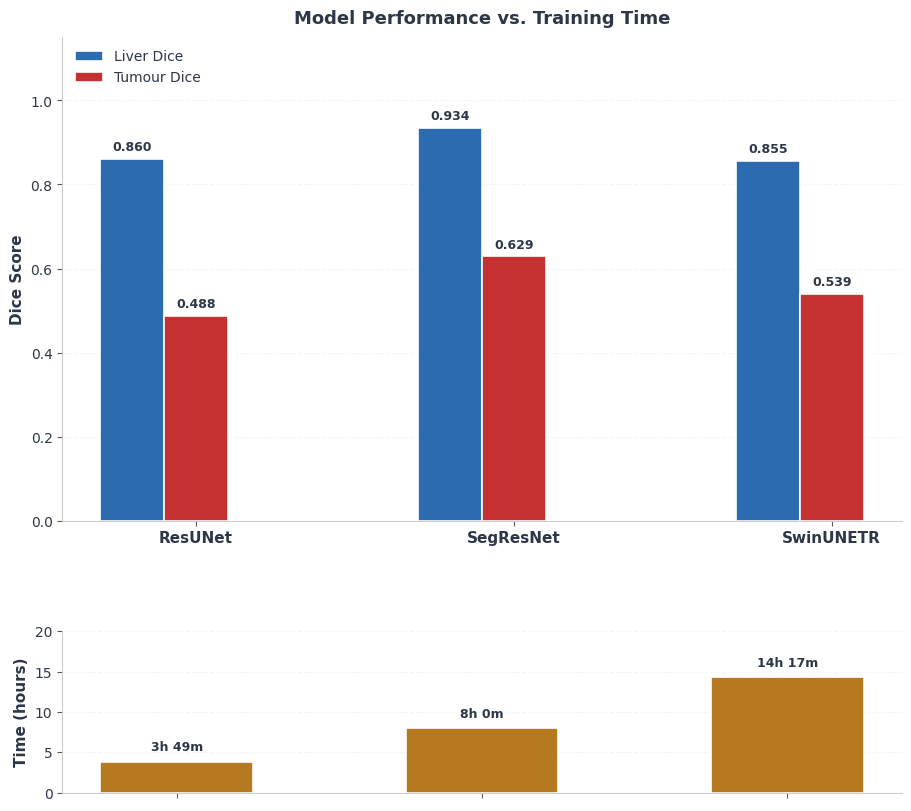

In [81]:
fig = plot_results(pre_strat)

### Test stats

In [111]:
raw_resunet_test = pd.read_csv('../files/server_logs/old_split/last_unet/validate/raw/reports/test_evaluation_results.csv')
raw_segresnet_test = pd.read_csv('../files/server_logs/old_split/last_segres/validate/raw/reports/test_evaluation_results.csv')
# SwinUNETR missing

post_resunet_test = pd.read_csv('../files/server_logs/old_split/last_unet/validate/post/reports/test_evaluation_results.csv')
post_segresnet_test = pd.read_csv('../files/server_logs/old_split/last_segres/validate/post/reports/test_evaluation_results.csv')
# SwinUNETR missing

In [9]:
raw_resunet_test.describe()

,dice_liver,dice_tumour,hd95_liver_mm,hd95_tumour_mm
count,20.000000,15.000000,20.000000,15.000000
mean,0.662266,0.221476,222.718005,173.084694
std,0.221254,0.213805,67.103723,91.550235
min,0.007153,0.000000,73.396187,60.016663
25%,0.609795,0.029909,181.922104,128.939377
50%,0.740547,0.102968,221.047310,146.017120
75%,0.782994,0.405533,254.167213,182.122421
max,0.898121,0.615285,400.530884,358.587921


In [128]:
raw_resunet_test[raw_segresnet_test['dice_tumour'].isna()]

,case_name,dice_liver,dice_tumour,hd95_liver_mm,hd95_tumour_mm
4,volume-32.nii,0.898121,NaN,216.695740,NaN
6,volume-34.nii,0.530068,NaN,73.396187,NaN
10,volume-38.nii,0.778257,NaN,232.488708,NaN
13,volume-41.nii,0.742832,NaN,217.083511,NaN
18,volume-47.nii,0.708949,NaN,293.191071,NaN


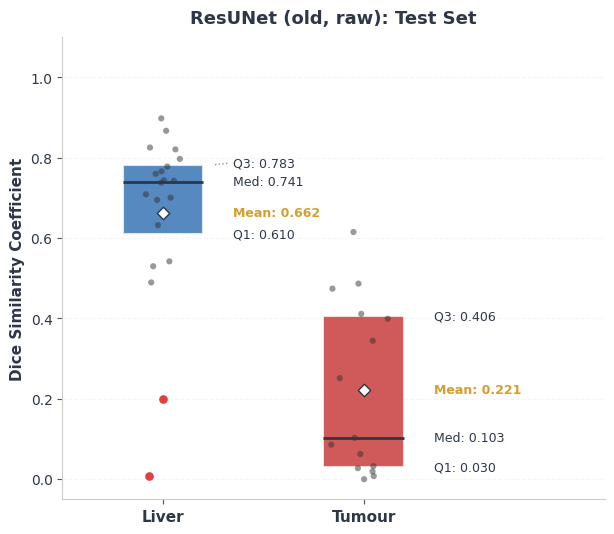

In [114]:
fig = plot_test_boxplots(raw_resunet_test, model_name="ResUNet (old, raw)", attach_hd95=False)

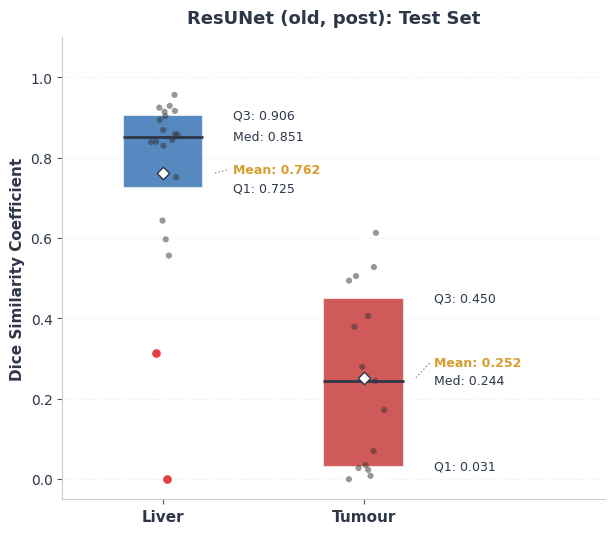

In [115]:
fig = plot_test_boxplots(post_resunet_test, model_name="ResUNet (old, post)")

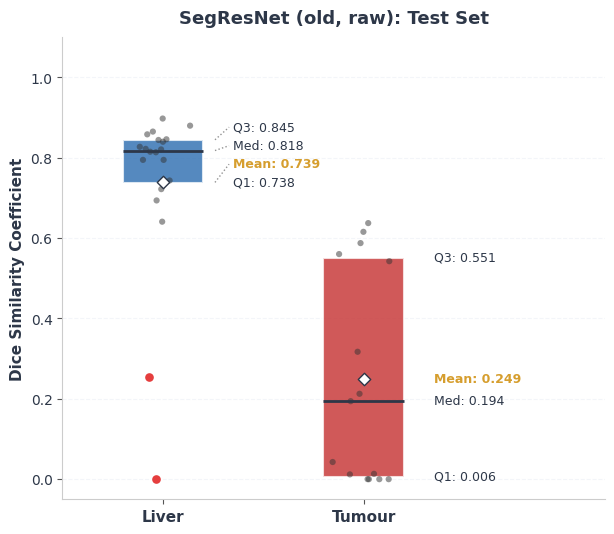

In [116]:
fig = plot_test_boxplots(raw_segresnet_test, model_name="SegResNet (old, raw)")

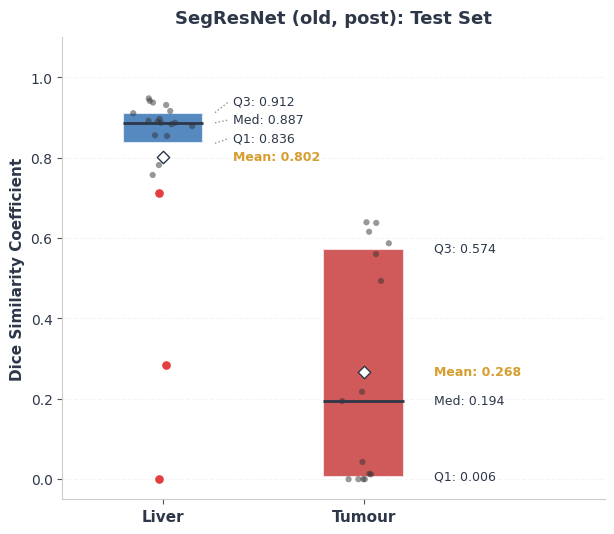

In [117]:
fig = plot_test_boxplots(post_segresnet_test, model_name="SegResNet (old, post)")

## Post stratification change
-----

In [118]:
unet = ModelTrainingResult(
    model_name="ResUNet",
    tumour_dice=0.260151,
    liver_dice=0.803238,
    mean_dice=0.553418,
    time="1h 38m 4s",
    epochs=138
)

segresnet = ModelTrainingResult(
    model_name="SegResNet",
    tumour_dice=0.418732,
    liver_dice=0.841984,
    mean_dice=0.647288,
    time="8h 59m 30s",
    epochs=200
)

swinunetr = ModelTrainingResult(
    model_name="SwinUNETR",
    tumour_dice=0.434832,
    liver_dice=0.807407,
    mean_dice=0.636023,
    time="48h 55m 59s",
    epochs=200
)

post_strat = [unet, segresnet, swinunetr]

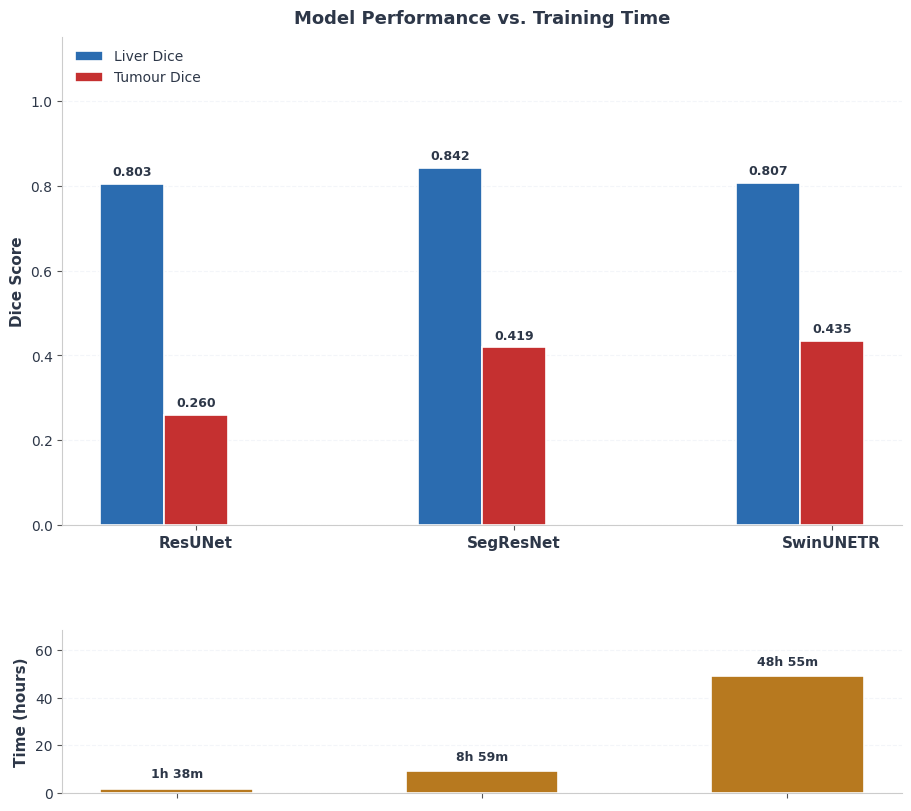

In [103]:
fig = plot_results(post_strat)

## Test set

In [119]:
raw_resunet_test = pd.read_csv('../files/server_logs/2.4-20260606_UNET/validate/raw/reports/test_evaluation_results.csv')
raw_segresnet_test = pd.read_csv('../files/server_logs/2.4.1-20260607_SEGRESNET/validate/raw/reports/test_evaluation_results.csv')
raw_swinunetr_test = pd.read_csv('../files/server_logs/2.4.4-20260617_SWINUNETR/validate/raw/reports/test_evaluation_results.csv')

post_resunet_test = pd.read_csv('../files/server_logs/2.4-20260606_UNET/validate/post/reports/test_evaluation_results.csv')
post_segresnet_test = pd.read_csv('../files/server_logs/2.4.1-20260607_SEGRESNET/validate/post/reports/test_evaluation_results.csv')
post_swinunetr_test = pd.read_csv('../files/server_logs/2.4.4-20260617_SWINUNETR/validate/post/reports/test_evaluation_results.csv')

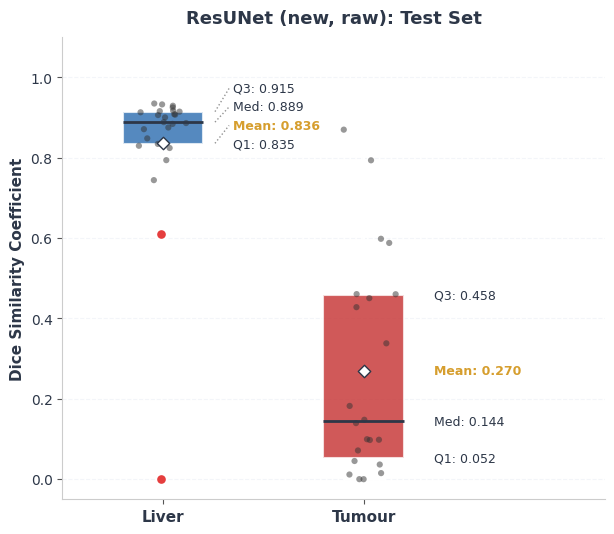

In [120]:
fig = plot_test_boxplots(raw_resunet_test, model_name="ResUNet (new, raw)")

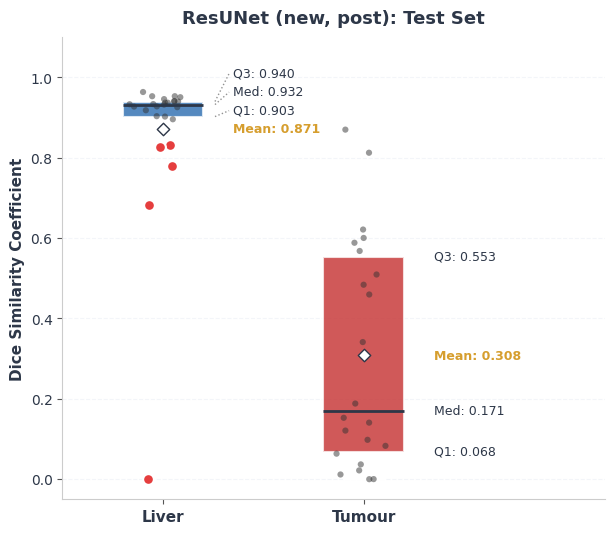

In [121]:
fig = plot_test_boxplots(post_resunet_test, model_name="ResUNet (new, post)")

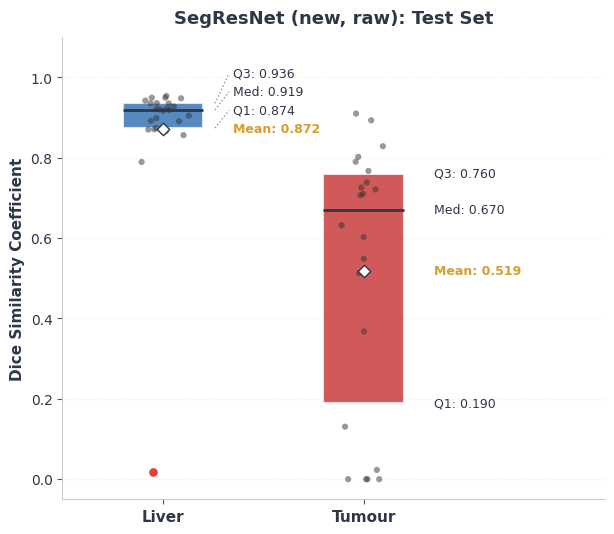

In [122]:
fig = plot_test_boxplots(raw_segresnet_test, model_name="SegResNet (new, raw)", attach_hd95=False)

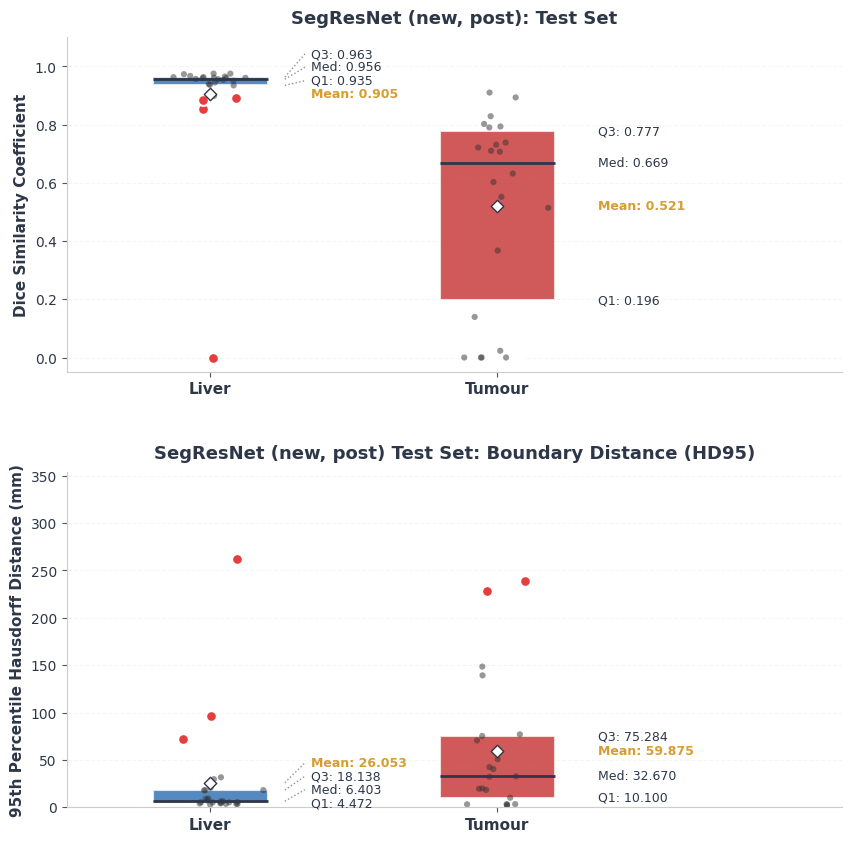

In [124]:
fig = plot_test_boxplots(post_segresnet_test, model_name="SegResNet (new, post)", attach_hd95=True)